<a href="https://colab.research.google.com/github/hjiwoong/ML/blob/main/Chapter05_%ED%9A%8C%EA%B7%80_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive


Saving NanumGothic.ttf to NanumGothic.ttf


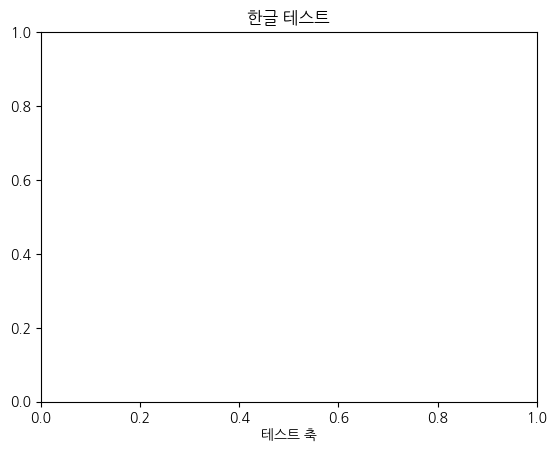

In [1]:
from google.colab import drive, files
drive.mount('/content/drive')

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import shutil, os

uploaded = files.upload()
font_dst = '/usr/local/share/fonts/NanumGothic.ttf'
os.makedirs('/usr/local/share/fonts', exist_ok=True)
shutil.copy('NanumGothic.ttf', font_dst)

fm.fontManager.ttflist = [
    f for f in fm.fontManager.ttflist
    if '/content/drive' not in f.fname
]

fm.fontManager.addfont(font_dst)
mpl.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots()
ax.set_title('한글 테스트')
ax.set_xlabel('테스트 축')
plt.show()

### 사이킷런 LinearRegression - 캘리포니아 주택 가격 예측

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [12]:
#캘리포니아 주택 가격 데이터셋
housing = fetch_california_housing()
caliDF = pd.DataFrame(housing.data, columns=housing.feature_names)
caliDF['Price'] = housing.target

print(caliDF.shape)
display(caliDF.head())
print('\n주요 피처 설명:')
print('  MedInc:    가구의 중간 소득 (중요한 예측 변수)')
print('  HouseAge:  주택의 중간 연령')
print('  AveRooms:  가구당 평균 방 개수')
print('  AveBedrms: 가구당 평균 침실 개수')
print('  Population:인구')
print('  AveOccup:  가구당 평균 거주자 수')
print('  Latitude:  위도')
print('  Longitude: 경도')

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



주요 피처 설명:
  MedInc:    가구의 중간 소득 (중요한 예측 변수)
  HouseAge:  주택의 중간 연령
  AveRooms:  가구당 평균 방 개수
  AveBedrms: 가구당 평균 침실 개수
  Population:인구
  AveOccup:  가구당 평균 거주자 수
  Latitude:  위도
  Longitude: 경도
